# Smart Metro Monitoring System — Anomaly Detection (LSTM Autoencoder → Isolation Forest)
This notebook builds an **end-to-end anomaly detection pipeline** for the MetroPT-3 Air Compressor / APU subsystem.

## What this notebook does
1. **Load & clean time-series data** (timestamp index, duplicates, column cleanup).
2. **Create evaluation labels** from known failure intervals (used for evaluation only).
3. **Hybrid gap handling**  
   - **Snap to 10s grid** to reduce timestamp jitter  
   - **Resample to fixed 10s rate**  
   - **Fill small gaps** (≤ 2 minutes):  
     - analog → time interpolation (limited)  
     - digital → forward-fill  
   - **Segment big gaps** (> 2 minutes): windows never cross them
4. **Time-based split (no leakage)**  
   - Train on data **before** a cut date  
   - Test on data **after** the cut date  
   - Fit scaler on **train-normal only**
5. **Model A — LSTM Autoencoder (sequence-based)**  
   - Train on **normal sequences** only  
   - Score windows by reconstruction error  
   - Threshold from **train-normal percentile** (same scoring rule for train/test ✅)
6. **Model B — Isolation Forest (window-statistics)**  
   - Convert windows into features (mean/std/min/max/RMS/slope)  
   - Train on **train-normal** windows  
   - Score + threshold from **train-normal percentile**
7. **Results summary**  
   - ROC-AUC, PR-AUC  
   - alert-rate (failure vs normal)  
   - confusion matrix  
   - plots to compare LSTM vs IF

> **Important evaluation note**  
A window is labeled **failure_window = 1** if it overlaps any known failure interval.  
This is evaluation labeling; models remain trained unsupervised on train-normal only.

---


## 0) Setup
We import required libraries and set display defaults.


In [ ]:
# ==============================
# 0) Setup
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

pd.set_option("display.max_columns", 200)
plt.rcParams["figure.figsize"] = (12, 4)

## 1) Load Dataset (Google Drive)
**Why**: parse `timestamp` and use it as index (time-series), sort, and drop duplicates to avoid resampling/windowing issues.


In [ ]:
# ==============================
# 1) Load Dataset (Google Drive)
# ==============================
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/ColabData/MetroPT3(AirCompressor).csv'

df_raw = pd.read_csv(
    file_path,
    parse_dates=["timestamp"],
    index_col="timestamp",
    thousands=",",
    decimal="."
)

# Some versions include an extra column
if "Unnamed: 0" in df_raw.columns:
    df_raw = df_raw.drop(columns=["Unnamed: 0"])

df_raw = df_raw.sort_index()
df_raw = df_raw[~df_raw.index.duplicated(keep="first")]

print("Shape:", df_raw.shape)
print("Time range:", df_raw.index.min(), "->", df_raw.index.max())
df_raw.head()


Mounted at /content/drive
Shape: (1516948, 15)
Time range: 2020-02-01 00:00:00 -> 2020-09-01 03:59:50


,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
timestamp,,,,,,,,,,,,,,,
2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


## 2) Define Sensor Columns
MetroPT-3 provides **7 analog** + **8 digital** sensors (15 total).
We keep them explicit so preprocessing and weighting are consistent.


In [ ]:
# ==============================
# 2) Column lists
# ==============================
ANALOG_COLS = ["TP2","TP3","H1","DV_pressure","Reservoirs","Oil_temperature","Motor_current"]
DIGITAL_COLS = ["COMP","DV_eletric","Towers","MPG","LPS","Pressure_switch","Oil_level","Caudal_impulses"]
FEATURE_COLS = ANALOG_COLS + DIGITAL_COLS

missing_cols = [c for c in FEATURE_COLS if c not in df_raw.columns]
if missing_cols:
    print("⚠️ Missing expected columns:", missing_cols)

print("Analog:", len([c for c in ANALOG_COLS if c in df_raw.columns]))
print("Digital:", len([c for c in DIGITAL_COLS if c in df_raw.columns]))


Analog: 7
Digital: 8


## 3) Create Failure Labels (for evaluation)
We create a binary label `failure` based on known failure start/end intervals.
Even for unsupervised models, we need labels to compute ROC-AUC / PR-AUC and confusion matrices.


In [ ]:
# ==============================
# 3) Failure Labeling (evaluation only)
# ==============================
failures = pd.DataFrame({
    "start": [
        "2020-04-18 00:00:00",
        "2020-05-29 23:30:00",
        "2020-06-05 10:00:00",
        "2020-07-15 14:30:00"
    ],
    "end": [
        "2020-04-18 23:59:00",
        "2020-05-30 06:00:00",
        "2020-06-07 14:30:00",
        "2020-07-15 19:00:00"
    ]
})

failures["start"] = pd.to_datetime(failures["start"])
failures["end"]   = pd.to_datetime(failures["end"])

df = df_raw.copy()
df["failure"] = 0
for _, row in failures.iterrows():
    mask = (df.index >= row["start"]) & (df.index < row["end"])
    df.loc[mask, "failure"] = 1

print(df["failure"].value_counts())
print("Failure ratio:", df["failure"].mean())
failures


failure
0    1486995
1      29953
Name: count, dtype: int64
Failure ratio: 0.019745568074845017


,start,end
0,2020-04-18 00:00:00,2020-04-18 23:59:00
1,2020-05-29 23:30:00,2020-05-30 06:00:00
2,2020-06-05 10:00:00,2020-06-07 14:30:00
3,2020-07-15 14:30:00,2020-07-15 19:00:00


## 4) Quick EDA (Focused for anomaly detection)
Goals:
- confirm sensor distributions (multi-modal operating modes)
- visualize key sensors over time
- confirm failure intervals alignment


Missing values (top 10):


,0
TP2,0
TP3,0
H1,0
DV_pressure,0
Reservoirs,0
Oil_temperature,0
Motor_current,0
COMP,0
DV_eletric,0
Towers,0


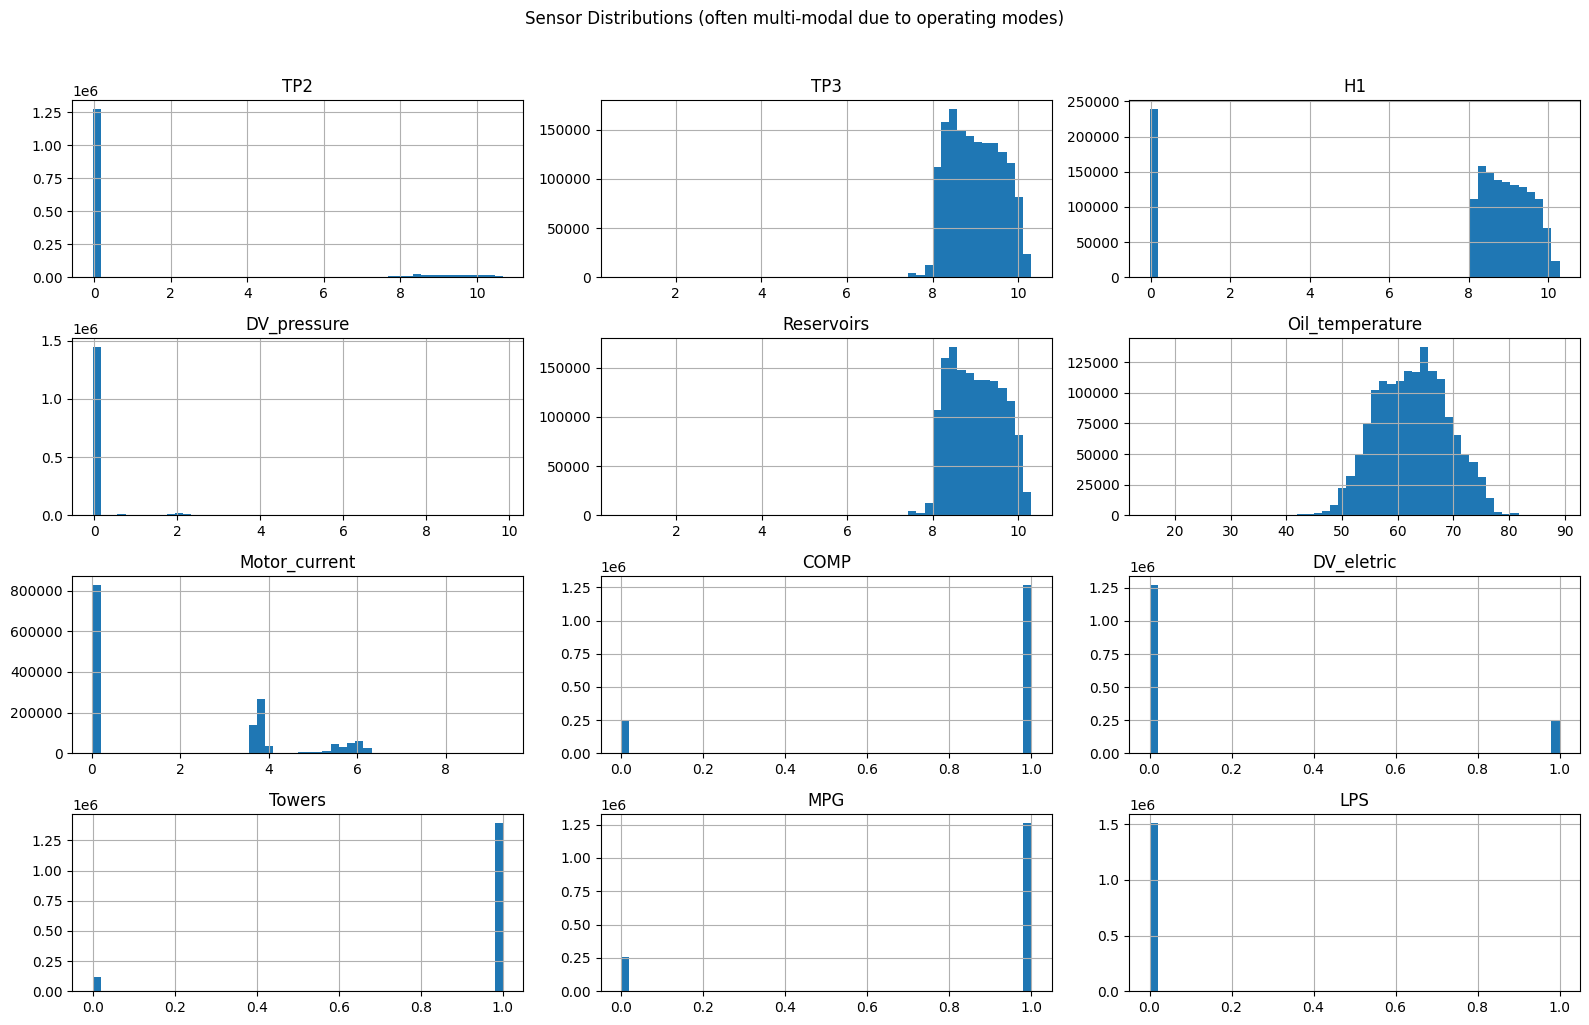

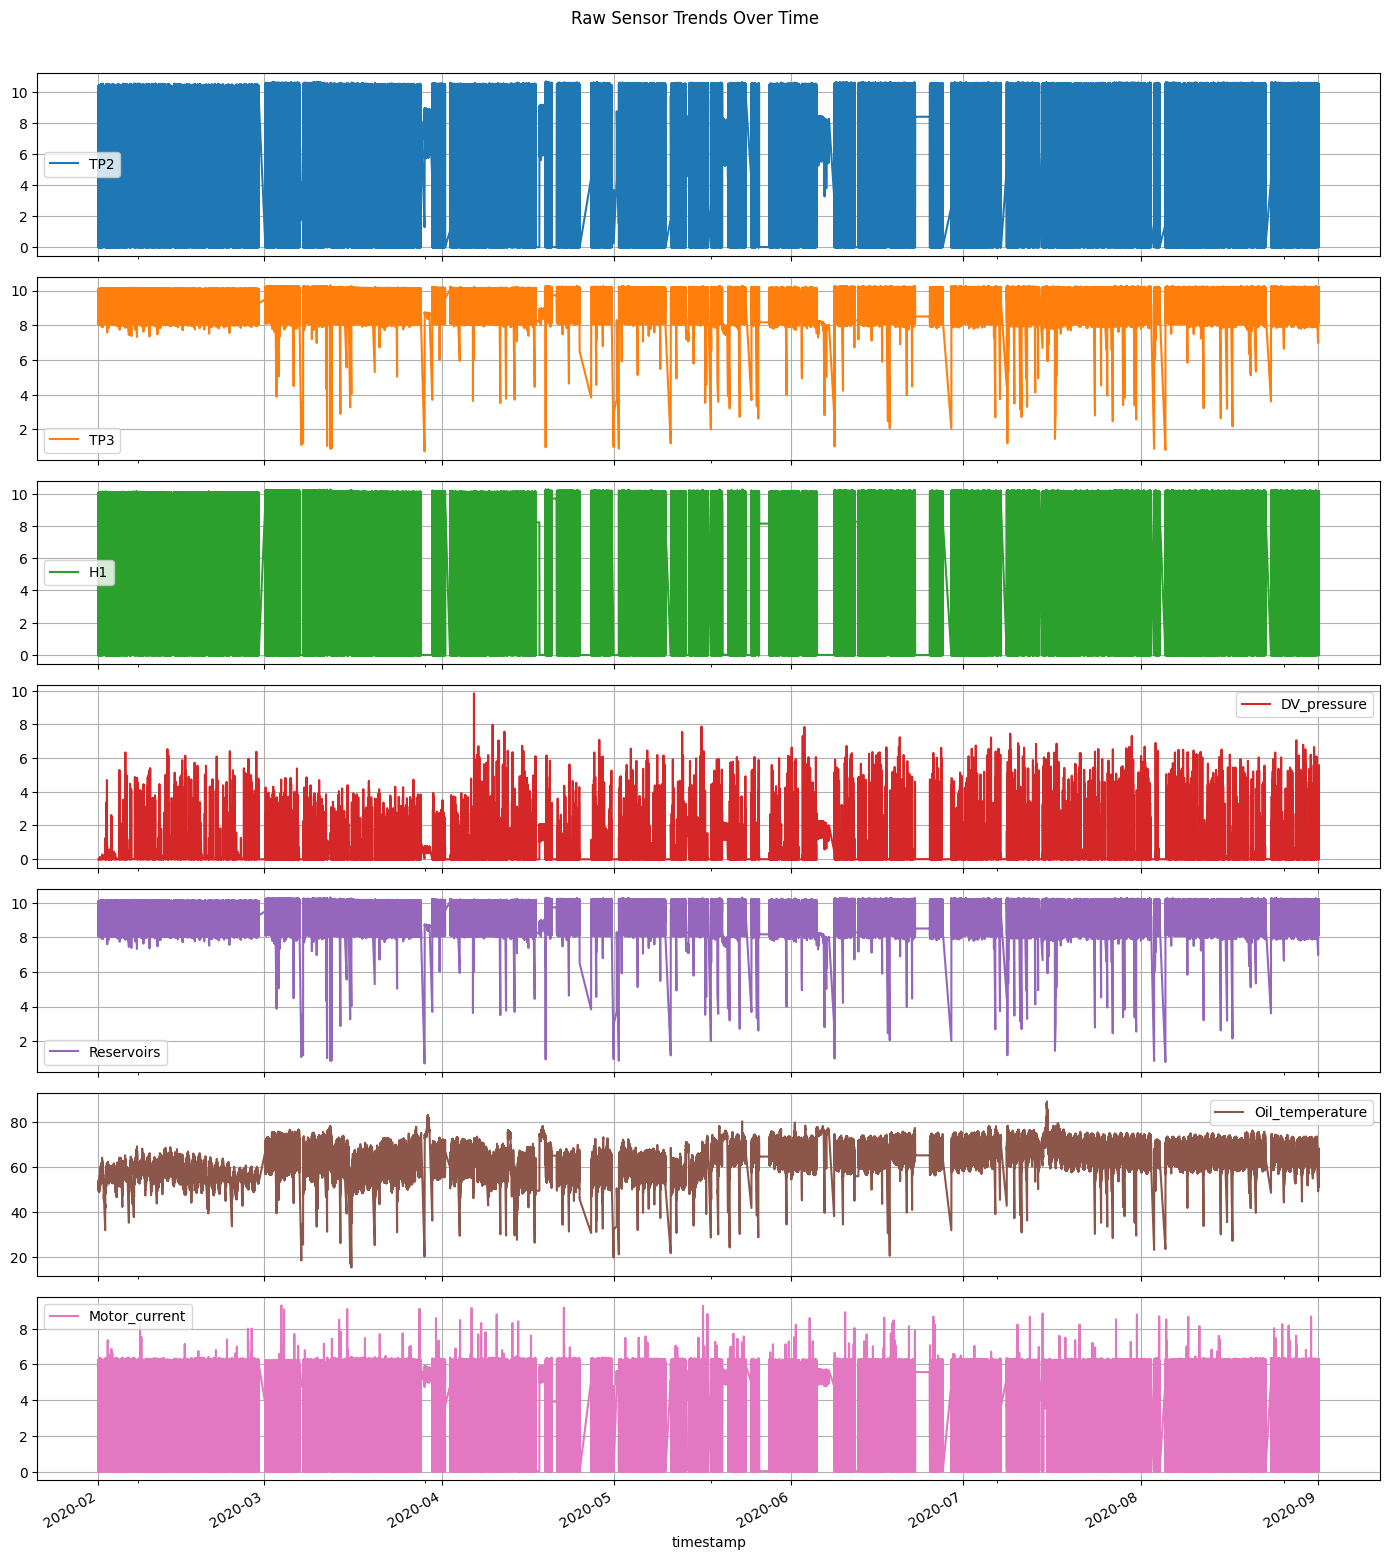

In [ ]:
# ==============================
# 4) Quick EDA
# ==============================
print("Missing values (top 10):")
display(df[FEATURE_COLS].isna().sum().sort_values(ascending=False).head(10))

# Distributions (subset)
sample_cols = [c for c in FEATURE_COLS if c in df.columns][:12]
df[sample_cols].hist(bins=50, figsize=(16, 10))
plt.suptitle("Sensor Distributions (often multi-modal due to operating modes)", y=1.02)
plt.tight_layout()
plt.show()

# Trend plot (key analogs)
sensors_to_plot = [c for c in ["TP2","TP3","H1","DV_pressure","Reservoirs","Oil_temperature","Motor_current"] if c in df.columns]
df[sensors_to_plot].plot(subplots=True, figsize=(14, 2.2*len(sensors_to_plot)), sharex=True, grid=True)
plt.suptitle("Raw Sensor Trends Over Time", y=1.01)
plt.tight_layout()
plt.show()


## 5) Hybrid Gap Handling (Fill small gaps, segment big gaps)
**Problem**: sampling is ~10 seconds but there are irregular gaps.

**Solution**:
1. Snap timestamps to 10s grid (reduce jitter)
2. Resample to fixed 10s rate
3. Fill **small gaps** (≤ 2 min):
   - digital: forward-fill
   - analog: time interpolation (limited)
4. Segment **big gaps** (> 2 min): windows never cross them


In [ ]:
# ==============================
# 5) Hybrid Gap Handling (Fixed & robust)
# ==============================
EXPECTED = "10s"
SMALL_GAP_MAX = pd.Timedelta("120s")   # <= 2 minutes
BIG_GAP_MIN   = pd.Timedelta("120s")   # > 2 minutes => segmentation boundary

# how many samples correspond to the small-gap limit (for interpolation limit)
MEDIUM_MAX = int(SMALL_GAP_MAX / pd.Timedelta(EXPECTED))

# (1) Snap timestamps to 10s grid (prefer floor to avoid pushing times forward)
df2 = df.copy()
df2.index = df2.index.floor(EXPECTED)

# Aggregate duplicates after snapping:
agg = {c: "mean" for c in ANALOG_COLS if c in df2.columns}
agg.update({c: "max" for c in DIGITAL_COLS if c in df2.columns})
keep_cols = [c for c in FEATURE_COLS if c in df2.columns] + ["failure"]
df2 = df2[keep_cols].groupby(level=0).agg({**agg, "failure":"max"}).sort_index()

# gap report (after snap)
time_diff_orig = df2.index.to_series().diff()
irregular = int((time_diff_orig > pd.Timedelta(EXPECTED)).sum())
big_gaps = time_diff_orig[time_diff_orig > BIG_GAP_MIN]
print(f"Total intervals: {len(df2)-1:,}")
print(f"Irregular intervals (>{EXPECTED}): {irregular:,} ({100*irregular/(len(df2)-1):.2f}%)")
print("Largest gap:", big_gaps.max() if len(big_gaps) else None)
print("Number of gaps > 2 min:", len(big_gaps))

# (2) Regular 10s timeline
df_rs = df2.resample(EXPECTED).asfreq()

# identify missing rows
rows_with_nan = df_rs[[c for c in FEATURE_COLS if c in df_rs.columns]].isna().any(axis=1)

# Build a "gap size" series aligned to the resampled grid:
gap_starts = time_diff_orig[time_diff_orig > pd.Timedelta(EXPECTED)].index
gap_starts_grid = pd.to_datetime(gap_starts).floor(EXPECTED)

gap_sizes = time_diff_orig.loc[gap_starts].copy()
gap_sizes.index = gap_starts_grid
gap_sizes = gap_sizes.groupby(level=0).max()

gap_size = pd.Series(index=df_rs.index, data=pd.Timedelta(0))
common_idx = gap_sizes.index.intersection(df_rs.index)
gap_size.loc[common_idx] = gap_sizes.loc[common_idx].values

# propagate only across missing rows
gap_size2 = gap_size.copy()
gap_size2.loc[~rows_with_nan] = pd.NaT
gap_size2 = gap_size2.ffill().fillna(pd.Timedelta(0))
gap_size = gap_size2

small_gap_rows = rows_with_nan & (gap_size <= SMALL_GAP_MAX)

df_filled = df_rs.copy()

# (3) Fill small gaps
# Digital -> ffill (then keep as 0/1)
dig_cols_present = [c for c in DIGITAL_COLS if c in df_filled.columns]
ana_cols_present = [c for c in ANALOG_COLS if c in df_filled.columns]

df_filled[dig_cols_present] = df_filled[dig_cols_present].ffill().round()

# Analog -> interpolate (limited)
df_filled[ana_cols_present] = df_filled[ana_cols_present].interpolate(
    method="time", limit=MEDIUM_MAX, limit_direction="forward"
)

# (4) Segmentation based on ORIGINAL big gaps
new_segment = (time_diff_orig > BIG_GAP_MIN).reindex(df_filled.index, fill_value=False)
new_segment.iloc[0] = True
df_filled["segment_id"] = new_segment.cumsum()

# Drop remaining NaNs (these correspond to big gaps not filled)
df_final = df_filled.dropna(subset=[c for c in FEATURE_COLS if c in df_filled.columns]).copy()

# Rebuild failure label after resampling/filling to align perfectly on grid
df_final["failure"] = 0
for _, row in failures.iterrows():
    start = pd.to_datetime(row["start"])
    end   = pd.to_datetime(row["end"])
    df_final.loc[(df_final.index >= start) & (df_final.index < end), "failure"] = 1

print("\nAfter hybrid handling:")
print("Rows:", len(df_final))
print("Segments:", df_final["segment_id"].nunique())
print("Time range:", df_final.index.min(), "->", df_final.index.max())
print("Remaining missing values:", int(df_final[[c for c in FEATURE_COLS if c in df_final.columns]].isna().sum().sum()))
df_final.head()


Total intervals: 1,504,106
Irregular intervals (>10s): 10,874 (0.72%)
Largest gap: 2 days 00:01:50
Number of gaps > 2 min: 326

After hybrid handling:
Rows: 1518621
Segments: 327
Time range: 2020-02-01 00:00:00 -> 2020-09-01 03:59:50
Remaining missing values: 0


,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses,failure,segment_id
timestamp,,,,,,,,,,,,,,,,,
2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.6000,0.04000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0,1
2020-02-01 00:00:10,-0.013,9.343,9.327,-0.022,9.343,53.6375,0.04125,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0,1
2020-02-01 00:00:20,-0.012,9.328,9.312,-0.022,9.328,53.4250,0.04000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0,1
2020-02-01 00:00:30,-0.012,9.318,9.302,-0.022,9.318,53.4750,0.04000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0,1
2020-02-01 00:00:40,-0.012,9.306,9.290,-0.024,9.308,53.5000,0.04000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0,1


## 6) Train/Test Split by Time (No Leakage)
We split chronologically:
- Train: before `cut_date`
- Test: on/after `cut_date`

Then we create `train_normal` (failure removed) to train unsupervised models on healthy data only.


In [ ]:
# ==============================
# 6) Time Split
# ==============================
cut_date = pd.Timestamp("2020-06-01")

train_df = df_final[df_final.index < cut_date].copy()
test_df  = df_final[df_final.index >= cut_date].copy()

print("Train range:", train_df.index.min(), "->", train_df.index.max(), "Rows:", len(train_df))
print("Test  range:", test_df.index.min(),  "->", test_df.index.max(),  "Rows:", len(test_df))

train_normal = train_df[train_df["failure"] == 0].copy()
print("Train normal rows:", len(train_normal))
print("Train failure rows removed:", int(train_df["failure"].sum()))


Train range: 2020-02-01 00:00:00 -> 2020-05-31 23:51:40 Rows: 856619
Test  range: 2020-06-01 00:32:00 -> 2020-09-01 03:59:50 Rows: 662002
Train normal rows: 845667
Train failure rows removed: 10952


## 7) Scaling (fit on train-normal only)
Why:
- Different sensors have different ranges/units.
- Fit only on train-normal to avoid leakage from failure behavior.


In [ ]:
# ==============================
# 7) Scaling
# ==============================
exclude = {"failure", "segment_id"}
feature_cols = [c for c in train_df.columns if c not in exclude]

scaler = StandardScaler()
scaler.fit(train_normal[feature_cols])

train_scaled = train_df.copy()
test_scaled  = test_df.copy()

train_scaled[feature_cols] = scaler.transform(train_df[feature_cols])
test_scaled[feature_cols]  = scaler.transform(test_df[feature_cols])

print("Scaling done ✅")
print("Num features:", len(feature_cols))


Scaling done ✅
Num features: 15


# Model A — LSTM Autoencoder (Sequence-based)
Isolation Forest uses hand-crafted window statistics.  
LSTM Autoencoder learns patterns directly from sequences:

- Train on **train-normal windows** only
- Reconstruct normal behavior
- Failures → higher reconstruction error

We also ensure:
✅ same scoring rule for train/test (so the threshold is correct)
✅ windows do not cross big gaps (segment-aware windowing)


## 8) Build LSTM Windows (segment-aware)
We create sequence windows of shape:
`[num_windows, window_size, num_features]`

A window is labeled `failure_window=1` if it overlaps a failure interval.


In [ ]:
# ==============================
# 8) LSTM window builder
# ==============================
def build_lstm_windows(df_scaled, feature_cols, window_size=60, step=5, min_seg_len=None):
    if min_seg_len is None:
        min_seg_len = window_size

    X_list = []
    meta_rows = []  # end_time, segment_id, failure_window

    for seg_id, seg in df_scaled.groupby("segment_id"):
        seg = seg.sort_index()
        n = len(seg)
        if n < min_seg_len:
            continue

        arr = seg[feature_cols].to_numpy(dtype=np.float32)
        fail = seg["failure"].to_numpy(dtype=np.int8)

        for start in range(0, n - window_size + 1, step):
            w = arr[start:start+window_size]  # (T, F)
            X_list.append(w)

            end_time = seg.index[start + window_size - 1]
            failure_window = int(fail[start:start+window_size].max() > 0)
            meta_rows.append((end_time, seg_id, failure_window))

    X = np.stack(X_list, axis=0) if len(X_list) else np.empty((0, window_size, len(feature_cols)), dtype=np.float32)
    meta = pd.DataFrame(meta_rows, columns=["window_end_time", "segment_id", "failure_window"])
    return X, meta

WINDOW_SIZE_LSTM = 60   # 10 minutes at 10s
STEP_LSTM = 5           # 50 seconds

X_lstm_train, meta_lstm_train = build_lstm_windows(
    train_scaled[train_scaled["failure"] == 0],  # train-normal only
    feature_cols,
    window_size=WINDOW_SIZE_LSTM,
    step=STEP_LSTM
)

X_lstm_test, meta_lstm_test = build_lstm_windows(
    test_scaled,  # contains failures
    feature_cols,
    window_size=WINDOW_SIZE_LSTM,
    step=STEP_LSTM
)

print("LSTM Train windows:", X_lstm_train.shape)
print("LSTM Test  windows:", X_lstm_test.shape)
meta_lstm_test.head()


LSTM Train windows: (167135, 60, 15)
LSTM Test  windows: (130805, 60, 15)


,window_end_time,segment_id,failure_window
0,2020-06-01 00:41:50,184,0
1,2020-06-01 00:42:40,184,0
2,2020-06-01 00:43:30,184,0
3,2020-06-01 00:44:20,184,0
4,2020-06-01 00:45:10,184,0


## 9) Define LSTM Autoencoder
Architecture:
- Encoder (LSTM 64 → LSTM 32)
- Bottleneck vector
- Decoder (RepeatVector → LSTM 32 → LSTM 64 → Dense)

We add:
- Dropout to reduce overfitting
- Gradient clipping for stability
- Early stopping & LR reduction


In [ ]:
# ==============================
# 9) LSTM Autoencoder
# ==============================
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

n_features = X_lstm_train.shape[-1]

lstm_ae = models.Sequential([
    layers.Input(shape=(WINDOW_SIZE_LSTM, n_features)),

    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),

    layers.LSTM(32, return_sequences=False),

    layers.RepeatVector(WINDOW_SIZE_LSTM),

    layers.LSTM(32, return_sequences=True),
    layers.Dropout(0.2),

    layers.LSTM(64, return_sequences=True),

    layers.TimeDistributed(layers.Dense(n_features))
])

opt = tf.keras.optimizers.Adam(1e-3, clipnorm=1.0)
lstm_ae.compile(optimizer=opt, loss="mse")
lstm_ae.summary()

cb = [
    callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5)
]


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 60, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 60, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 60, 15)         │           975 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,023 (261.81 KB)

 Trainable params: 67,023 (261.81 KB)

 Non-trainable params: 0 (0.00 B)

## 10) Train LSTM Autoencoder (time-aware validation)
Instead of random `validation_split`, we create a **chronological validation** slice from train-normal windows
to avoid optimistic validation in time-series.


In [ ]:
# ==============================
# 10) Time-aware validation split
# ==============================
# Create a time-based validation set (last 10% windows by end_time)
order = np.argsort(meta_lstm_train["window_end_time"].values)
X_tr_all = X_lstm_train[order]
meta_tr_all = meta_lstm_train.iloc[order].reset_index(drop=True)

n = len(X_tr_all)
val_size = max(1, int(0.1 * n))
X_tr = X_tr_all[:-val_size]
X_val = X_tr_all[-val_size:]

print("Train windows:", X_tr.shape, " | Val windows:", X_val.shape)

history = lstm_ae.fit(
    X_tr, X_tr,
    epochs=15,
    batch_size=360,
    validation_data=(X_val, X_val),
    callbacks=cb,
    verbose=1
)


Train windows: (150422, 60, 15)  | Val windows: (16713, 60, 15)
Epoch 1/15
418/418 ━━━━━━━━━━━━━━━━━━━━ 320s 742ms/step - loss: 0.2880 - val_loss: 0.9377 - learning_rate: 0.0010
Epoch 2/15
418/418 ━━━━━━━━━━━━━━━━━━━━ 307s 733ms/step - loss: 0.1777 - val_loss: 0.7121 - learning_rate: 0.0010
Epoch 3/15
418/418 ━━━━━━━━━━━━━━━━━━━━ 299s 715ms/step - loss: 0.1566 - val_loss: 0.7015 - learning_rate: 0.0010
Epoch 4/15
418/418 ━━━━━━━━━━━━━━━━━━━━ 303s 725ms/step - loss: 0.1446 - val_loss: 0.7051 - learning_rate: 0.0010
Epoch 5/15
418/418 ━━━━━━━━━━━━━━━━━━━━ 305s 730ms/step - loss: 0.1391 - val_loss: 0.7000 - learning_rate: 0.0010
Epoch 6/15
418/418 ━━━━━━━━━━━━━━━━━━━━ 294s 703ms/step - loss: 0.1347 - val_loss: 0.7055 - learning_rate: 0.0010
Epoch 7/15
418/418 ━━━━━━━━━━━━━━━━━━━━ 325s 711ms/step - loss: 0.1301 - val_loss: 0.7011 - learning_rate: 0.0010
Epoch 8/15
418/418 ━━━━━━━━━━━━━━━━━━━━ 304s 728ms/step - loss: 0.1256 - val_loss: 0.7183 - learning_rate: 0.0010
Epoch 9/15
418/418 ━━━━━

## 11) LSTM Scoring: Reconstruction Error (consistent train/test ✅)
We compute reconstruction error with:
- **feature weights**: analog=1.0, digital=0.3  
- then per-feature error (mean over time)
- take **top 30% most-error features** and average → final score

✅ We use the **same function** for train and test scores (so thresholds are valid).


In [ ]:
# ==============================
# 11) Consistent reconstruction error
# ==============================
def lstm_recon_error(X, X_pred, feature_cols, analog_cols, digital_weight=0.3, topk_frac=0.3):
    # weights
    w = np.ones((len(feature_cols),), dtype=np.float32)
    for i, c in enumerate(feature_cols):
        w[i] = 1.0 if c in analog_cols else digital_weight

    err = np.square(X - X_pred) * w[None, None, :]
    per_feat = err.mean(axis=1)  # (N,F) mean over time
    k = max(1, int(topk_frac * per_feat.shape[1]))
    score = np.sort(per_feat, axis=1)[:, -k:].mean(axis=1)  # top-k mean
    return score

# Test scores
X_pred_test = lstm_ae.predict(X_lstm_test, batch_size=256, verbose=1)
meta_lstm_test["recon_error"] = lstm_recon_error(
    X_lstm_test, X_pred_test, feature_cols, ANALOG_COLS, digital_weight=0.3, topk_frac=0.3
)

# Train-normal scores (for threshold)
X_pred_tr = lstm_ae.predict(X_lstm_train, batch_size=256, verbose=0)
recon_err_tr = lstm_recon_error(
    X_lstm_train, X_pred_tr, feature_cols, ANALOG_COLS, digital_weight=0.3, topk_frac=0.3
)

meta_lstm_test.head()


511/511 ━━━━━━━━━━━━━━━━━━━━ 90s 174ms/step


,window_end_time,segment_id,failure_window,recon_error
0,2020-06-01 00:41:50,184,0,0.089550
1,2020-06-01 00:42:40,184,0,0.054336
2,2020-06-01 00:43:30,184,0,0.052356
3,2020-06-01 00:44:20,184,0,0.009612
4,2020-06-01 00:45:10,184,0,0.007814


## 12) LSTM Evaluation (ROC-AUC, PR-AUC)
- ROC-AUC: ranking quality across thresholds
- PR-AUC: more informative when failures are rare (class imbalance)


In [ ]:
# ==============================
# 12) LSTM evaluation
# ==============================
y_lstm = meta_lstm_test["failure_window"].values
score_lstm = meta_lstm_test["recon_error"].values

lstm_roc = roc_auc_score(y_lstm, score_lstm)
lstm_pr  = average_precision_score(y_lstm, score_lstm)

print("LSTM-AE ROC-AUC:", lstm_roc)
print("LSTM-AE PR-AUC :", lstm_pr)
print("Failure-window ratio:", y_lstm.mean())


LSTM-AE ROC-AUC: 0.8008870715728789
LSTM-AE PR-AUC : 0.07858249998779304
Failure-window ratio: 0.0285998241657429


In [ ]:
# ==============================
# SAVE — Models, Scaler, Metadata
# ==============================
import joblib
import json
import os

# Create save directory in Google Drive
SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/SmartMetro_Models"
os.makedirs(SAVE_DIR, exist_ok=True)

# 1) Save LSTM model
lstm_ae.save(f"{SAVE_DIR}/lstm_ae.keras")
print("✅ LSTM model saved")

# 2) Save scaler
joblib.dump(scaler, f"{SAVE_DIR}/scaler.pkl")
print("✅ Scaler saved")

# 3) Save threshold + metadata
lstm_threshold = float(np.percentile(recon_err_tr, 95))

metadata = {
    "lstm_threshold": lstm_threshold,
    "window_size": int(WINDOW_SIZE_LSTM),
    "step": int(STEP_LSTM),
    "roc_auc": 0.8008,
    "pr_auc": 0.0785,
    "feature_cols": feature_cols,
    "analog_cols": ANALOG_COLS,
    "digital_cols": DIGITAL_COLS
}

with open(f"{SAVE_DIR}/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print("✅ Metadata saved")

print(f"\n📁 All saved to: {SAVE_DIR}")
print(f"   LSTM threshold (95th percentile): {lstm_threshold:.6f}")

✅ LSTM model saved
✅ Scaler saved
✅ Metadata saved

📁 All saved to: /content/drive/MyDrive/Colab Notebooks/SmartMetro_Models
   LSTM threshold (95th percentile): 1.041282


In [ ]:
# ==============================
# FAULT LOCALIZATION
# ==============================

def fault_localization(X, X_pred, feature_cols, analog_cols, digital_weight=0.3):
    """
    For each window, compute per-sensor reconstruction error.
    Returns a DataFrame with one row per window, one column per sensor.
    """
    # Feature weights
    w = np.array([
        1.0 if c in analog_cols else digital_weight
        for c in feature_cols
    ], dtype=np.float32)

    # Per-sensor error: squared error weighted, averaged over time
    err = np.square(X - X_pred) * w[None, None, :]  # (N, T, F)
    per_sensor = err.mean(axis=1)                    # (N, F)

    return pd.DataFrame(per_sensor, columns=feature_cols)


# Compute per-sensor errors on test set
# X_pred_test already computed in Cell 11
per_sensor_errors = fault_localization(
    X_lstm_test, X_pred_test, feature_cols, ANALOG_COLS
)

print("Per-sensor error matrix shape:", per_sensor_errors.shape)
per_sensor_errors.head()

Per-sensor error matrix shape: (130805, 15)


,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,0.027988,0.019454,0.011988,0.049816,0.019261,0.023669,0.041966,0.002598,0.002476,0.238428,0.002330,0.000952,0.003569,0.000568,0.000575
1,0.017092,0.001567,0.007392,0.043951,0.001609,0.014980,0.028344,0.001657,0.002001,0.127957,0.002020,0.001126,0.003177,0.000816,0.000601
2,0.087529,0.006479,0.073061,0.008670,0.006041,0.015061,0.033117,0.014342,0.010856,0.015716,0.010004,0.001013,0.001692,0.001634,0.000790
3,0.001514,0.005275,0.001563,0.001160,0.004624,0.006669,0.021881,0.000207,0.000345,0.000150,0.000333,0.000181,0.000187,0.000654,0.000270
4,0.000764,0.002490,0.000719,0.000782,0.002585,0.006927,0.019255,0.000105,0.000166,0.000077,0.000169,0.000098,0.000144,0.000512,0.000273


In [ ]:
# ==============================
# FAULT LOCALIZATION — Rank Culprits
# ==============================

# Get anomalous windows only (above threshold)
lstm_threshold = float(np.percentile(recon_err_tr, 95))
meta_lstm_test["recon_error"] = lstm_recon_error(
    X_lstm_test, X_pred_test, feature_cols, ANALOG_COLS
)
meta_lstm_test["is_anomaly"] = (
    meta_lstm_test["recon_error"] > lstm_threshold
).astype(int)

# Add top 3 culprit sensors per window
def get_top_sensors(row, n=3):
    return ", ".join(row.nlargest(n).index.tolist())

per_sensor_errors_reset = per_sensor_errors.reset_index(drop=True)
meta_lstm_test_reset = meta_lstm_test.reset_index(drop=True)

meta_lstm_test_reset["top_sensors"] = per_sensor_errors_reset.apply(
    get_top_sensors, axis=1
)

# Filter to anomalous windows only
anomalies = meta_lstm_test_reset[
    meta_lstm_test_reset["is_anomaly"] == 1
].copy()

print(f"Total anomalous windows: {len(anomalies)}")
print(f"Out of total windows:    {len(meta_lstm_test_reset)}")
print(f"Anomaly rate:            {len(anomalies)/len(meta_lstm_test_reset)*100:.2f}%")
print()
print("Sample anomalies with culprit sensors:")
anomalies[["window_end_time", "recon_error",
           "failure_window", "top_sensors"]].head(10)

Total anomalous windows: 24366
Out of total windows:    130805
Anomaly rate:            18.63%

Sample anomalies with culprit sensors:


,window_end_time,recon_error,failure_window,top_sensors
82,2020-06-01 01:50:10,1.761474,0,"DV_pressure, Towers, Oil_temperature"
83,2020-06-01 01:51:00,1.702645,0,"DV_pressure, Towers, Oil_temperature"
84,2020-06-01 01:51:50,1.718029,0,"DV_pressure, Towers, H1"
85,2020-06-01 01:52:40,1.723373,0,"DV_pressure, Towers, H1"
86,2020-06-01 01:53:30,1.725694,0,"DV_pressure, Towers, H1"
87,2020-06-01 01:54:20,1.726743,0,"DV_pressure, Towers, H1"
88,2020-06-01 01:55:10,1.724246,0,"DV_pressure, Towers, H1"
89,2020-06-01 01:56:00,1.720001,0,"DV_pressure, Towers, H1"
90,2020-06-01 01:56:50,1.717073,0,"DV_pressure, Towers, H1"
91,2020-06-01 01:57:40,1.737853,0,"DV_pressure, Towers, Motor_current"


In [ ]:
# ==============================
# FAULT FINGERPRINTING
# ==============================
from collections import Counter

# Count how often each sensor appears as a top culprit
sensor_counts = Counter()
for sensors in anomalies["top_sensors"]:
    for s in sensors.split(", "):
        sensor_counts[s] += 1

# Convert to dataframe
sensor_freq = pd.DataFrame(
    sensor_counts.most_common(),
    columns=["sensor", "count"]
)
sensor_freq["pct_of_anomalies"] = (
    sensor_freq["count"] / len(anomalies) * 100
).round(1)

print("=" * 50)
print("🔍 SENSOR FAULT FREQUENCY")
print("=" * 50)
print(sensor_freq.to_string(index=False))

# ── Fault type classification ──────────────────────
def classify_fault(top_sensors):
    sensors = set(top_sensors.split(", "))

    pressure  = {"TP2", "TP3", "DV_pressure", "Reservoirs"}
    thermal   = {"Oil_temperature", "Motor_current"}
    flow      = {"H1", "Caudal_impulses"}
    digital   = {"COMP", "DV_eletric", "Towers", "MPG",
                 "LPS", "Pressure_switch", "Oil_level"}

    scores = {
        "Pressure Fault" : len(sensors & pressure),
        "Thermal Fault"  : len(sensors & thermal),
        "Flow Fault"     : len(sensors & flow),
        "Digital Fault"  : len(sensors & digital),
    }
    return max(scores, key=scores.get)

anomalies["fault_type"] = anomalies["top_sensors"].apply(classify_fault)

# Summary
fault_summary = anomalies.groupby("fault_type").agg(
    count=("fault_type", "count"),
    avg_recon_error=("recon_error", "mean"),
    true_failures=("failure_window", "sum")
).sort_values("count", ascending=False)

fault_summary["pct"] = (
    fault_summary["count"] / len(anomalies) * 100
).round(1)

print("\n")
print("=" * 50)
print("🧬 FAULT TYPE BREAKDOWN")
print("=" * 50)
print(fault_summary.to_string())

# Save fault localization results
fault_output = anomalies[[
    "window_end_time", "recon_error",
    "failure_window", "top_sensors", "fault_type"
]]
fault_output.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/SmartMetro_Models/fault_localization.csv",
    index=False
)
print("\n✅ Fault localization saved to Drive")

🔍 SENSOR FAULT FREQUENCY
         sensor  count  pct_of_anomalies
            TP2  14113              57.9
             H1  13609              55.9
  Motor_current  12053              49.5
Pressure_switch   8721              35.8
Oil_temperature   7569              31.1
      Oil_level   6327              26.0
    DV_pressure   4778              19.6
         Towers   3171              13.0
     Reservoirs   1200               4.9
            TP3    814               3.3
            LPS    627               2.6
Caudal_impulses    109               0.4
     DV_eletric      3               0.0
            MPG      3               0.0
           COMP      1               0.0


🧬 FAULT TYPE BREAKDOWN
                count  avg_recon_error  true_failures   pct
fault_type                                                 
Pressure Fault  15792         1.907507            554  64.8
Digital Fault    8307         3.174311             26  34.1
Thermal Fault     206         2.015893              4 

## 13) LSTM Operational Threshold + Alerts
We pick a percentile of train-normal scores as an operational threshold.
- Example: 95th percentile  
- Anything above it → `alert=1`

Then we report:
- alert-rate during failure windows
- alert-rate during normal windows
- confusion matrix


In [ ]:
# ==============================
# 13) LSTM thresholding + report
# ==============================
TH_PCT_LSTM = 95
thr_lstm = np.percentile(recon_err_tr, TH_PCT_LSTM)
print(f"LSTM threshold ({TH_PCT_LSTM}th pct train-normal):", thr_lstm)

tmp_lstm = meta_lstm_test.copy()
tmp_lstm["alert"] = (tmp_lstm["recon_error"] >= thr_lstm).astype(int)

fail_alert_rate_lstm = tmp_lstm.loc[tmp_lstm["failure_window"]==1, "alert"].mean()
norm_alert_rate_lstm = tmp_lstm.loc[tmp_lstm["failure_window"]==0, "alert"].mean()

print("Alert rate during failure windows:", fail_alert_rate_lstm)
print("Alert rate during non-failure windows:", norm_alert_rate_lstm)

cm_lstm = confusion_matrix(tmp_lstm["failure_window"], tmp_lstm["alert"])
print("\nConfusion Matrix [ [TN FP], [FN TP] ]:\n", cm_lstm)
print("\nClassification report:")
print(classification_report(tmp_lstm["failure_window"], tmp_lstm["alert"], digits=4))


LSTM threshold (95th pct train-normal): 1.0412824
Alert rate during failure windows: 0.15610799251537022
Alert rate during non-failure windows: 0.18716552288610463

Confusion Matrix [ [TN FP], [FN TP] ]:
 [[103282  23782]
 [  3157    584]]

Classification report:
              precision    recall  f1-score   support

           0     0.9703    0.8128    0.8846    127064
           1     0.0240    0.1561    0.0416      3741

    accuracy                         0.7941    130805
   macro avg     0.4972    0.4845    0.4631    130805
weighted avg     0.9433    0.7941    0.8605    130805



## 14) Plot LSTM Scores Over Time (Test)
We plot reconstruction error over time and shade failure intervals.


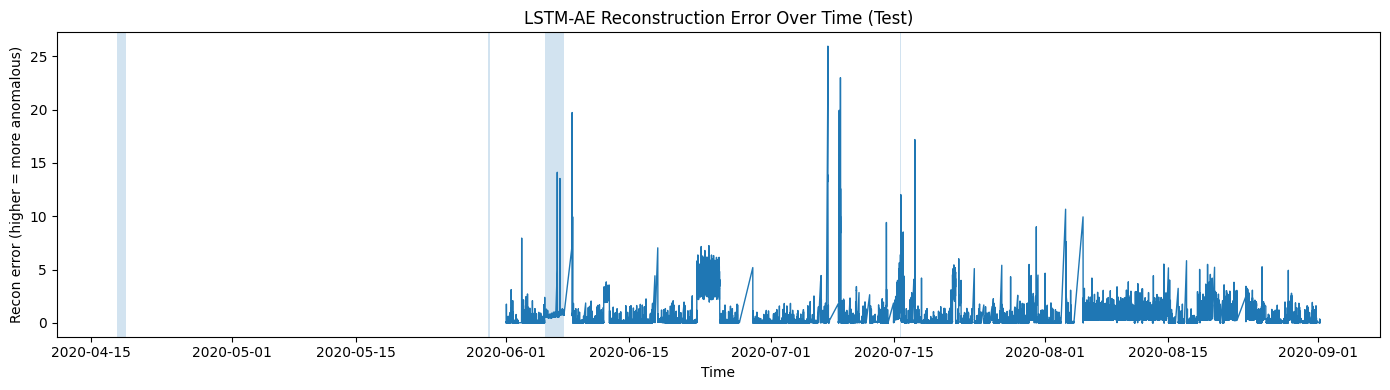

In [ ]:
# ==============================
# 14) Plot LSTM recon error
# ==============================
tmp = meta_lstm_test.sort_values("window_end_time").copy()

plt.figure(figsize=(14,4))
plt.plot(tmp["window_end_time"], tmp["recon_error"], linewidth=1)
plt.title("LSTM-AE Reconstruction Error Over Time (Test)")
plt.xlabel("Time")
plt.ylabel("Recon error (higher = more anomalous)")

for _, row in failures.iterrows():
    plt.axvspan(row["start"], row["end"], alpha=0.2)

plt.tight_layout()
plt.show()


# Model B — Isolation Forest (Window-statistics)
Isolation Forest expects a feature vector per sample, so we convert each window into statistics per sensor:

Per sensor:
- mean, std, min, max, RMS, slope  → **6 features**
Total per window = `6 * num_sensors`


## 15) Build Isolation Forest Window Features (segment-aware)
We build features for:
- Train windows: **train-normal only**
- Test windows: full test (includes failures)

A window is labeled `failure_window=1` if it overlaps any failure interval.


In [ ]:
# ==============================
# 15) IF feature engineering (mean/std/min/max/RMS/slope)
# ==============================
def rms(x, axis=0):
    return np.sqrt(np.mean(np.square(x), axis=axis))

def window_slopes(w: np.ndarray) -> np.ndarray:
    T = w.shape[0]
    t = np.arange(T, dtype=np.float32)
    slopes = np.empty(w.shape[1], dtype=np.float32)
    for j in range(w.shape[1]):
        slopes[j] = np.polyfit(t, w[:, j].astype(np.float32), 1)[0]
    return slopes

def build_if_features(df_scaled, feature_cols, window_size=60, step=10, min_seg_len=None):
    if min_seg_len is None:
        min_seg_len = window_size

    X_list = []
    meta_rows = []  # end_time, segment_id, failure_window

    for seg_id, seg in df_scaled.groupby("segment_id"):
        seg = seg.sort_index()
        n = len(seg)
        if n < min_seg_len:
            continue

        arr = seg[feature_cols].to_numpy(dtype=np.float32)
        fail = seg["failure"].to_numpy(dtype=np.int8)

        for start in range(0, n - window_size + 1, step):
            w = arr[start:start + window_size]  # (T, F)

            m  = w.mean(axis=0)
            s  = w.std(axis=0, ddof=0)
            mn = w.min(axis=0)
            mx = w.max(axis=0)
            r  = rms(w, axis=0)
            sl = window_slopes(w)

            feats = np.concatenate([m, s, mn, mx, r, sl], axis=0)
            X_list.append(feats)

            end_time = seg.index[start + window_size - 1]
            failure_window = int(fail[start:start + window_size].max() > 0)
            meta_rows.append((end_time, seg_id, failure_window))

    n_feat = len(feature_cols)
    X = np.vstack(X_list) if len(X_list) else np.empty((0, 6 * n_feat), dtype=np.float32)
    meta = pd.DataFrame(meta_rows, columns=["window_end_time", "segment_id", "failure_window"])
    return X, meta

WINDOW_SIZE_IF = 60
STEP_IF = 10

X_if_train, meta_if_train = build_if_features(
    train_scaled[train_scaled["failure"] == 0],  # train-normal only
    feature_cols,
    window_size=WINDOW_SIZE_IF,
    step=STEP_IF
)

X_if_test, meta_if_test = build_if_features(
    test_scaled,
    feature_cols,
    window_size=WINDOW_SIZE_IF,
    step=STEP_IF
)

print("IF Train features:", X_if_train.shape)
print("IF Test  features:", X_if_test.shape)
meta_if_test.head()


IF Train features: (83609, 90)
IF Test  features: (65437, 90)


,window_end_time,segment_id,failure_window
0,2020-06-01 00:41:50,184,0
1,2020-06-01 00:43:30,184,0
2,2020-06-01 00:45:10,184,0
3,2020-06-01 00:46:50,184,0
4,2020-06-01 00:48:30,184,0


## 16) Train Isolation Forest + Score Windows
We flip the sign of `decision_function` so:
- higher `anomaly_score` = more anomalous.


In [ ]:
# ==============================
# 16) Train IF + score
# ==============================
iso = IsolationForest(
    n_estimators=500,
    contamination=0.005,
    max_samples=256,
    max_features=0.7,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

iso.fit(X_if_train)

meta_if_test = meta_if_test.copy()
meta_if_test["anomaly_score"] = -iso.decision_function(X_if_test)
meta_if_test.head()


,window_end_time,segment_id,failure_window,anomaly_score
0,2020-06-01 00:41:50,184,0,-0.221798
1,2020-06-01 00:43:30,184,0,-0.189265
2,2020-06-01 00:45:10,184,0,-0.259050
3,2020-06-01 00:46:50,184,0,-0.268270
4,2020-06-01 00:48:30,184,0,-0.267368


## 17) IF Evaluation (ROC-AUC, PR-AUC)


In [ ]:
# ==============================
# 17) IF evaluation
# ==============================
y_if = meta_if_test["failure_window"].values
score_if = meta_if_test["anomaly_score"].values

if_roc = roc_auc_score(y_if, score_if)
if_pr  = average_precision_score(y_if, score_if)

print("Isolation Forest ROC-AUC:", if_roc)
print("Isolation Forest PR-AUC :", if_pr)
print("Failure-window ratio:", y_if.mean())


Isolation Forest ROC-AUC: 0.9573461843981986
Isolation Forest PR-AUC : 0.23814089079992182
Failure-window ratio: 0.02859238657028898


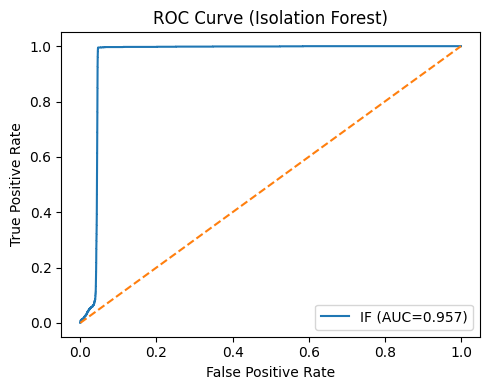

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y_true = y_if
y_score = score_if  # IF anomaly score

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"IF (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Isolation Forest)")
plt.legend()
plt.tight_layout()
plt.savefig("Fig3_ROC_IF.png", dpi=300, bbox_inches="tight")
plt.show()

## 18) IF Thresholding + Alerts (train-normal percentile)
Operational threshold:
- compute train-normal scores
- choose a percentile (e.g., 95th)
- score >= threshold → alert=1


In [ ]:
# ==============================
# 18) IF thresholding + report
# ==============================
train_score_if = -iso.decision_function(X_if_train)

TH_PCT_IF = 95
thr_if = np.percentile(train_score_if, TH_PCT_IF)
print(f"IF threshold ({TH_PCT_IF}th pct of train-normal):", thr_if)

tmp_if = meta_if_test.copy()
tmp_if["alert"] = (tmp_if["anomaly_score"] >= thr_if).astype(int)

fail_alert_rate_if = tmp_if.loc[tmp_if["failure_window"]==1, "alert"].mean()
norm_alert_rate_if = tmp_if.loc[tmp_if["failure_window"]==0, "alert"].mean()

print("Alert rate during failure windows:", fail_alert_rate_if)
print("Alert rate during non-failure windows:", norm_alert_rate_if)

cm_if = confusion_matrix(tmp_if["failure_window"], tmp_if["alert"])
print("\nConfusion Matrix [ [TN FP], [FN TP] ]:\n", cm_if)
print("\nClassification report:")
print(classification_report(tmp_if["failure_window"], tmp_if["alert"], digits=4))

# Save windows table (optional for later use)
tmp_if_out = tmp_if.copy()
tmp_if_out.rename(columns={"alert":"is_anomaly"}, inplace=True)
tmp_if_out.to_csv("windows_with_is_anomaly_if.csv", index=False)
print("Saved: windows_with_is_anomaly_if.csv")


IF threshold (95th pct of train-normal): -0.04875592936442259
Alert rate during failure windows: 0.9951897381079636
Alert rate during non-failure windows: 0.04752540666393984

Confusion Matrix [ [TN FP], [FN TP] ]:
 [[60545  3021]
 [    9  1862]]

Classification report:
              precision    recall  f1-score   support

           0     0.9999    0.9525    0.9756     63566
           1     0.3813    0.9952    0.5514      1871

    accuracy                         0.9537     65437
   macro avg     0.6906    0.9738    0.7635     65437
weighted avg     0.9822    0.9537    0.9635     65437

Saved: windows_with_is_anomaly_if.csv


In [ ]:
# ==============================
# SAVE — Isolation Forest (main anomaly detector) + threshold + metadata
# ==============================
# This is the REAL anomaly-detection IF (Model B of this notebook), NOT the one
# from PdM-Classifier.ipynb. The backend must load THIS one.
#
# Pipeline (must be reproduced exactly at inference):
#   1) scale the 15 RAW channels with the SAME StandardScaler used by the LSTM
#      (saved as lstm_scaler_sd.pkl / scaler.pkl) -- fit on train-normal only
#   2) build windows (window=60, step=10), segment-aware
#   3) engineer 90 stat features = [mean, std, min, max, rms, slope] x 15 channels
#      (6 blocks, each block in feature_cols order)  -> NO second scaler here
#   4) anomaly_score = -iso.decision_function(X)   (negated: higher = more anomalous)
#   5) alert if anomaly_score >= raw_threshold (thr_if, 95th pct of train-normal)
import joblib, json, os
import numpy as np

SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/SmartMetro_Models"
os.makedirs(SAVE_DIR, exist_ok=True)

# 1) trained Isolation Forest
joblib.dump(iso, f"{SAVE_DIR}/if_anomaly.pkl")
print("✅ Isolation Forest saved -> if_anomaly.pkl")

# 2) operational threshold (raw -decision_function scale)
joblib.dump(float(thr_if), f"{SAVE_DIR}/if_threshold.pkl")
print(f"✅ IF threshold saved -> if_threshold.pkl  (raw = {float(thr_if):.6f})")

# 3) metadata — everything the backend needs to reproduce IF inference + normalize score to 0-1
if_metadata = {
    "model_file": "if_anomaly.pkl",
    "scaler_file": "lstm_scaler_sd.pkl",          # SHARED StandardScaler, applied to raw channels BEFORE windowing
    "scaler_applies_to": "raw_15_channels_before_windowing",
    "post_engineering_scaler": None,               # there is NO scaler on the 90 engineered features
    "window_size": int(WINDOW_SIZE_IF),            # 60
    "step": int(STEP_IF),                          # 10
    "n_features": int(6 * len(feature_cols)),      # 90
    "feature_cols": list(feature_cols),            # 15 channels, order used for windowing/engineering
    "analog_cols": list(ANALOG_COLS),
    "digital_cols": list(DIGITAL_COLS),
    "stat_order": ["mean", "std", "min", "max", "rms", "slope"],  # 90-feat layout: 6 blocks x 15, this order
    "score_transform": "negative_decision_function",  # anomaly_score = -iso.decision_function(X)
    "raw_threshold": float(thr_if),
    "threshold_percentile": 95,
    # raw train-normal score stats -> normalize raw score to 0-1 in the backend (then apply 0.65 dashboard threshold)
    "train_score_min": float(np.min(train_score_if)),
    "train_score_max": float(np.max(train_score_if)),
    "train_score_mean": float(np.mean(train_score_if)),
    "train_score_std": float(np.std(train_score_if)),
    "train_score_p50": float(np.percentile(train_score_if, 50)),
    "train_score_p90": float(np.percentile(train_score_if, 90)),
    "train_score_p95": float(np.percentile(train_score_if, 95)),
    "train_score_p99": float(np.percentile(train_score_if, 99)),
    "roc_auc": float(if_roc),
    "pr_auc": float(if_pr),
}

with open(f"{SAVE_DIR}/if_metadata.json", "w") as f:
    json.dump(if_metadata, f, indent=2)
print("✅ IF metadata saved -> if_metadata.json")
print(json.dumps(if_metadata, indent=2))


In [ ]:
# ==============================
# IF-GATED FAULT LOCALIZATION  (LSTM = localization only)
# Detection    = Isolation Forest (anomaly_score >= thr_if)
# Localization = LSTM per-sensor recon error, ONLY on IF-flagged windows.
# The LSTM threshold is NOT used here -> its false positives can't leak in.
# ==============================
import numpy as np, pandas as pd

SENSOR_COLS = list(feature_cols)  # 15 channels, same order as per_sensor_errors

# 1) LSTM per-sensor errors, tagged with each window's end-time
#    (per_sensor_errors is row-aligned with meta_lstm_test)
pse = per_sensor_errors.copy()
pse["window_end_time"] = meta_lstm_test["window_end_time"].values

# 2) windows the IF flags anomalous (its own train-normal threshold)
if_flags = meta_if_test[["window_end_time", "failure_window", "anomaly_score"]].copy()
if_flags["if_alert"] = (if_flags["anomaly_score"] >= thr_if).astype(int)
if_anom = if_flags[if_flags["if_alert"] == 1]

# 3) attach LSTM per-sensor errors to IF-flagged windows (match on end-time)
loc = if_anom.merge(pse, on="window_end_time", how="inner")
print(f"IF-flagged windows: {len(if_anom)}  |  localized: {len(loc)}")

# 4) top-3 culprit sensors + fault type per flagged window
def top_sensors(row, n=3):
    return row[SENSOR_COLS].astype(float).nlargest(n).index.tolist()

def classify_fault(sensors):
    s = set(sensors)
    groups = {
        "Pressure Fault": {"TP2", "TP3", "DV_pressure", "Reservoirs"},
        "Thermal Fault" : {"Oil_temperature", "Motor_current"},
        "Flow Fault"    : {"H1", "Caudal_impulses"},
        "Digital Fault" : {"COMP", "DV_eletric", "Towers", "MPG",
                           "LPS", "Pressure_switch", "Oil_level"},
    }
    scores = {k: len(s & v) for k, v in groups.items()}
    return max(scores, key=scores.get)

loc["top_sensors"] = loc.apply(top_sensors, axis=1)
loc["fault_type"]  = loc["top_sensors"].apply(classify_fault)

# 5) fingerprint: ALL IF-flagged vs IF-flagged TRUE-failure windows (the honest one)
print("\nFault-type % - ALL IF-flagged windows:")
print((loc["fault_type"].value_counts(normalize=True) * 100).round(1))

print("\nFault-type % - IF-flagged TRUE-failure windows only:")
true_fail = loc[loc["failure_window"] == 1]
print((true_fail["fault_type"].value_counts(normalize=True) * 100).round(1))
print(f"\n(true-failure windows localized: {len(true_fail)})")
print("Sanity: air-leak failures should localize mostly to 'Pressure Fault'.")


## 19) Plot IF Scores Over Time (Test)


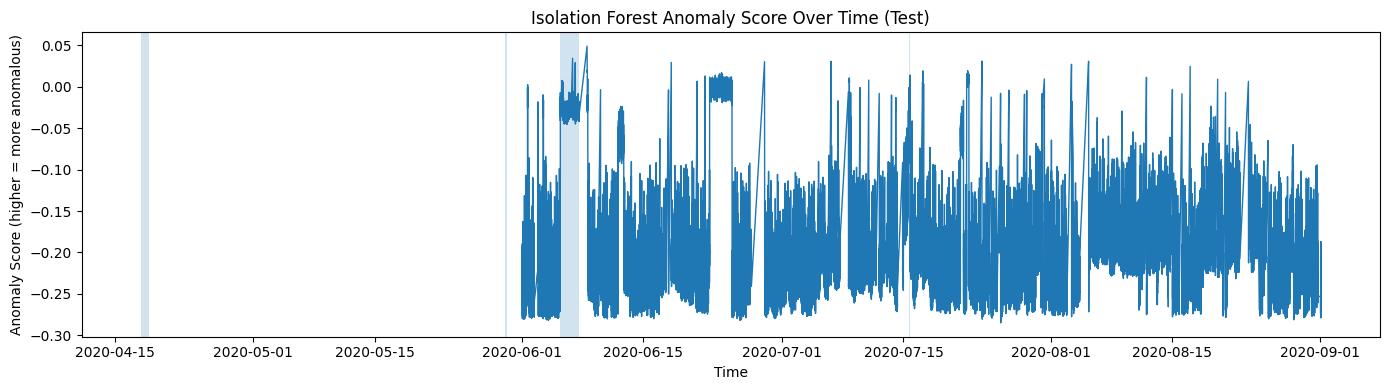

In [ ]:
# ==============================
# 19) Plot IF anomaly score
# ==============================
tmp = meta_if_test.sort_values("window_end_time").copy()

plt.figure(figsize=(14,4))
plt.plot(tmp["window_end_time"], tmp["anomaly_score"], linewidth=1)
plt.title("Isolation Forest Anomaly Score Over Time (Test)")
plt.xlabel("Time")
plt.ylabel("Anomaly Score (higher = more anomalous)")

for _, row in failures.iterrows():
    plt.axvspan(row["start"], row["end"], alpha=0.2)

plt.tight_layout()
plt.show()


# Results Summary (IF vs LSTM)
This section produces:
- comparison table (ROC-AUC, PR-AUC, alert-rates)
- confusion matrices
- a combined plot for both scores
- PR curves (recommended for imbalanced failures)


## 20) Results Summary Table (ROC/PR + alert-rate + confusion matrix)


In [ ]:
# ==============================
# 20) Results summary table
# ==============================
def summarize_scores(y_true, y_score, y_pred, name):
    roc = roc_auc_score(y_true, y_score)
    pr  = average_precision_score(y_true, y_score)
    cm  = confusion_matrix(y_true, y_pred)
    alert_rate_all = y_pred.mean()
    alert_rate_fail = y_pred[y_true==1].mean() if (y_true==1).any() else np.nan
    alert_rate_norm = y_pred[y_true==0].mean() if (y_true==0).any() else np.nan
    return {
        "Model": name,
        "ROC-AUC": roc,
        "PR-AUC": pr,
        "Alert rate (all)": alert_rate_all,
        "Alert rate (failure windows)": alert_rate_fail,
        "Alert rate (normal windows)": alert_rate_norm,
        "TN": int(cm[0,0]), "FP": int(cm[0,1]),
        "FN": int(cm[1,0]), "TP": int(cm[1,1]),
    }

rows = [
    summarize_scores(y_lstm, score_lstm, tmp_lstm["alert"].values, "LSTM Autoencoder"),
    summarize_scores(y_if, score_if, tmp_if["alert"].values, "Isolation Forest"),
]
summary_df = pd.DataFrame(rows)
display(summary_df)


,Model,ROC-AUC,PR-AUC,Alert rate (all),Alert rate (failure windows),Alert rate (normal windows),TN,FP,FN,TP
0,LSTM Autoencoder,0.800887,0.078582,0.186277,0.156108,0.187166,103282,23782,3157,584
1,Isolation Forest,0.957346,0.238141,0.074621,0.995190,0.047525,60545,3021,9,1862


## 21) Combined Score Plot (LSTM vs IF)
We overlay both models' scores over time (test period).
Note: scores have different scales, but this plot is great for showing *when* each model spikes.


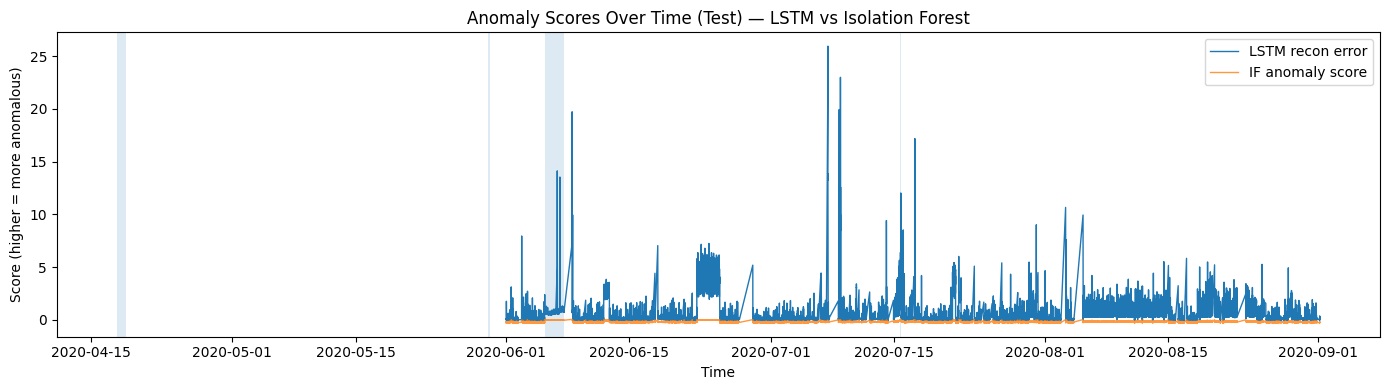

In [ ]:
# ==============================
# 21) Overlay scores over time
# ==============================
t_if = meta_if_test.sort_values("window_end_time")
t_l  = meta_lstm_test.sort_values("window_end_time")

plt.figure(figsize=(14,4))
plt.plot(t_l["window_end_time"], t_l["recon_error"], label="LSTM recon error", linewidth=1)
plt.plot(t_if["window_end_time"], t_if["anomaly_score"], label="IF anomaly score", linewidth=1, alpha=0.8)

for _, row in failures.iterrows():
    plt.axvspan(row["start"], row["end"], alpha=0.15)

plt.title("Anomaly Scores Over Time (Test) — LSTM vs Isolation Forest")
plt.xlabel("Time")
plt.ylabel("Score (higher = more anomalous)")
plt.legend()
plt.tight_layout()
plt.show()


## 22) Precision–Recall Curves (recommended for rare failures)
PR curves are more informative than accuracy when failure windows are rare.


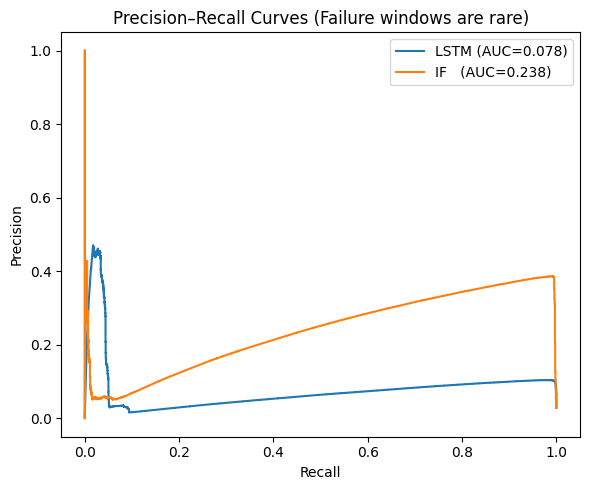

In [ ]:
# ==============================
# 22) Precision–Recall curves
# ==============================
from sklearn.metrics import precision_recall_curve, auc

p_l, r_l, _ = precision_recall_curve(y_lstm, score_lstm)
p_i, r_i, _ = precision_recall_curve(y_if, score_if)

plt.figure(figsize=(6,5))
plt.plot(r_l, p_l, label=f"LSTM (AUC={auc(r_l,p_l):.3f})")
plt.plot(r_i, p_i, label=f"IF   (AUC={auc(r_i,p_i):.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves (Failure windows are rare)")
plt.legend()
plt.tight_layout()
plt.show()


## 23) Export: LSTM window table with alerts (optional)
This is useful later if you want to:
- join anomaly flags back to timeline
- build a classifier using is_anomaly as a feature


In [ ]:
# ==============================
# 23) Save LSTM window outputs
# ==============================
tmp_lstm_out = tmp_lstm.copy()
tmp_lstm_out.rename(columns={"alert":"is_anomaly"}, inplace=True)
tmp_lstm_out.to_csv("windows_with_is_anomaly_lstm.csv", index=False)
print("Saved: windows_with_is_anomaly_lstm.csv")
tmp_lstm_out.head()


Saved: windows_with_is_anomaly_lstm.csv


,window_end_time,segment_id,failure_window,recon_error,is_anomaly
0,2020-06-01 00:41:50,184,0,0.089550,0
1,2020-06-01 00:42:40,184,0,0.054336,0
2,2020-06-01 00:43:30,184,0,0.052356,0
3,2020-06-01 00:44:20,184,0,0.009612,0
4,2020-06-01 00:45:10,184,0,0.007814,0
